<a href="https://colab.research.google.com/github/muktatech-ai/muktatech-ai.github.io/blob/main/InventoryGen_Final_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Requirements

Python 3.11+

Libraries Used

• pandas

• numpy

• matplotlib

• scikit-learn

• python-docx

• google.colab

#README
How to Use InventoryGen

1. Upload inventory dataset.

2. Run all notebook cells.

3. AI analyses inventory.

4. Dashboard is generated.

5. Ask questions using InventoryGen AI Assistant.

6. Generate Executive Report.

# InventoryGen: AI-Powered Smart Inventory Management System

Capstone Project

Project Overview

InventoryGen is an AI-powered inventory management system designed for small supermarkets and grocery stores. The system predicts product expiry risk using machine learning and provides intelligent recommendations to reduce food waste, improve inventory management, and maximize business profits.

Objectives

- Predict expiry risk (Low, Medium, High)
- Reduce food waste
- Help sellers make better inventory decisions
- Recommend actions such as discounts and stock monitoring
- Build a scalable AI solution for future retail businesses

Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Google Colab

In [ ]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

Loading the Dataset

The dataset contains inventory information for 120 supermarket products. Each row represents one product and includes inventory details, sales information, pricing, demand, and expiry-related attributes.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving InventoryGen_Dataset_v5_0 (1).xlsx to InventoryGen_Dataset_v5_0 (1).xlsx


In [ ]:
# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_excel("InventoryGen_Dataset_v5_0 (1).xlsx")

print("✅ Dataset Loaded Successfully!")

display(df.head())

✅ Dataset Loaded Successfully!


,Product ID,Product,Category,Quantity,Expiry Days Left,Sales/Day,Profit Margin,Discount,Demand,AI Confidence (%),Estimated Daily Revenue (AED),Estimated Daily Profit (AED),Unit Price (AED),Stock Cover Ratio,Daily Units Sold,Discount %,Warehouse / Source Location,Category,Warehouse / Source Location.1
0,1,Apple,Fruits,564,10,0.27,0.31,Low,Low,82,1255.5486,362.4264,8.5,0.370370,152.28,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Fruits,"Al Aweer Fruit & Vegetable Market, Dubai"
1,2,Banana,Fruits,28,2,0.31,0.25,High,Medium,88,39.1468,3.3418,5.5,1.612903,8.68,0.18,"Al Aweer Fruit & Vegetable Market, Dubai",Vegetables,"Al Aweer Fruit & Vegetable Market, Dubai"
2,3,Orange,Fruits,100,6,0.41,0.28,Low,High,81,258.5050,66.6250,6.5,0.406504,41.00,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Dairy,"National Industries Park, Dubai"
3,4,Grapes,Fruits,120,4,0.36,0.27,Medium,High,82,471.7440,93.3120,12.0,0.694444,43.20,0.09,"Al Aweer Fruit & Vegetable Market, Dubai",Bakery,"Al Quoz Industrial Area, Dubai"
4,5,Mango,Fruits,60,7,0.51,0.32,Low,High,83,267.1380,79.8660,9.0,0.280112,30.60,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Beverages,"Jebel Ali Free Zone (JAFZA), Dubai"


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (120, 19)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Product ID                     120 non-null    int64  
 1   Product                        120 non-null    object 
 2   Category                       120 non-null    object 
 3   Quantity                       120 non-null    int64  
 4   Expiry Days Left               120 non-null    int64  
 5   Sales/Day                      120 non-null    float64
 6   Profit Margin                  120 non-null    float64
 7   Discount                       120 non-null    object 
 8   Demand                         120 non-null    object 
 9   AI Confidence (%)              120 non-null    int64  
 10  Estimated Daily Revenue (AED)  120 non-null    float64
 11  Estimated Daily Profit (AED)   120 non-null    float64
 12  Unit Price (AED)               120 non-null    flo

In [ ]:
df.describe()

,Product ID,Quantity,Expiry Days Left,Sales/Day,Profit Margin,AI Confidence (%),Estimated Daily Revenue (AED),Estimated Daily Profit (AED),Unit Price (AED),Stock Cover Ratio,Daily Units Sold,Discount %
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.00000
mean,60.500000,192.150000,67.950000,0.328583,0.251500,84.150000,686.336232,140.687741,13.625000,0.399369,57.872083,0.05225
std,34.785054,157.917681,96.013204,0.093335,0.063095,3.198345,642.872672,133.951467,11.082246,0.633128,42.187795,0.04577
min,1.000000,20.000000,1.000000,0.140000,0.150000,80.000000,22.386000,0.000000,2.000000,0.006512,4.200000,0.03000
25%,30.750000,80.000000,6.000000,0.250000,0.200000,82.000000,265.028250,50.556000,6.000000,0.033206,29.500000,0.03000
50%,60.500000,149.500000,13.000000,0.320000,0.240000,84.000000,471.582000,92.636000,9.000000,0.234255,45.020000,0.03000
75%,90.250000,260.000000,102.250000,0.380000,0.292500,86.000000,858.243750,158.932200,18.000000,0.490196,76.722500,0.03000
max,120.000000,800.000000,354.000000,0.630000,0.420000,99.000000,2960.779500,640.993500,55.000000,5.000000,232.000000,0.18000


In [ ]:
df.isnull().sum()

,0
Product ID,0
Product,0
Category,0
Quantity,0
Expiry Days Left,0
Sales/Day,0
Profit Margin,0
Discount,0
Demand,0
AI Confidence (%),0


# Exploring the Dataset

Before building the machine learning model, it is important to understand the structure and quality of the dataset.This step examines the number of records, data types, statistical summary, missing values, and duplicate records.

In [ ]:
# ==========================================================
# DATASET SHAPE
# ==========================================================

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 120
Number of Columns: 19


In [ ]:
df.isnull().sum()

,0
Product ID,0
Product,0
Category,0
Quantity,0
Expiry Days Left,0
Sales/Day,0
Profit Margin,0
Discount,0
Demand,0
AI Confidence (%),0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.dtypes

,0
Product ID,int64
Product,object
Category,object
Quantity,int64
Expiry Days Left,int64
Sales/Day,float64
Profit Margin,float64
Discount,object
Demand,object
AI Confidence (%),int64


In [ ]:
df.head()

,Product ID,Product,Category,Quantity,Expiry Days Left,Sales/Day,Profit Margin,Discount,Demand,AI Confidence (%),Estimated Daily Revenue (AED),Estimated Daily Profit (AED),Unit Price (AED),Stock Cover Ratio,Daily Units Sold,Discount %,Warehouse / Source Location,Category,Warehouse / Source Location.1
0,1,Apple,Fruits,564,10,0.27,0.31,Low,Low,82,1255.5486,362.4264,8.5,0.370370,152.28,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Fruits,"Al Aweer Fruit & Vegetable Market, Dubai"
1,2,Banana,Fruits,28,2,0.31,0.25,High,Medium,88,39.1468,3.3418,5.5,1.612903,8.68,0.18,"Al Aweer Fruit & Vegetable Market, Dubai",Vegetables,"Al Aweer Fruit & Vegetable Market, Dubai"
2,3,Orange,Fruits,100,6,0.41,0.28,Low,High,81,258.5050,66.6250,6.5,0.406504,41.00,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Dairy,"National Industries Park, Dubai"
3,4,Grapes,Fruits,120,4,0.36,0.27,Medium,High,82,471.7440,93.3120,12.0,0.694444,43.20,0.09,"Al Aweer Fruit & Vegetable Market, Dubai",Bakery,"Al Quoz Industrial Area, Dubai"
4,5,Mango,Fruits,60,7,0.51,0.32,Low,High,83,267.1380,79.8660,9.0,0.280112,30.60,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Beverages,"Jebel Ali Free Zone (JAFZA), Dubai"


#  Data Cleaning

Data cleaning ensures that the dataset is accurate, consistent, and suitable for machine learning. This includes removing duplicate columns, checking for missing values, and verifying that the dataset is free from duplicate records.

In [ ]:
# ==========================================================
# REMOVE DUPLICATE COLUMNS
# ==========================================================

columns_to_remove = [
    "Category.1",
    "Warehouse / Source Location.1"
]

# Remove only if they exist
df = df.drop(columns=[col for col in columns_to_remove if col in df.columns])

print("Duplicate columns removed successfully!")
print("Current Shape:", df.shape)

Duplicate columns removed successfully!
Current Shape: (120, 18)


In [ ]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : Product ID
1 : Product
2 : Category
3 : Quantity
4 : Expiry Days Left
5 : Sales/Day
6 : Profit Margin
7 : Discount
8 : Demand
9 : AI Confidence (%)
10 : Estimated Daily Revenue (AED)
11 : Estimated Daily Profit (AED)
12 : Unit Price (AED)
13 : Stock Cover Ratio
14 : Daily Units Sold
15 : Discount %
16 : Warehouse / Source Location
17 : Category 


In [ ]:
# ==========================================================
# REMOVE DUPLICATE CATEGORY COLUMN
# ==========================================================

# Keep only the first 17 columns
df = df.iloc[:, :17]

print("✅ Duplicate column removed successfully.")
print("New Dataset Shape:", df.shape)

✅ Duplicate column removed successfully.
New Dataset Shape: (120, 17)


In [ ]:
df.columns.tolist()

['Product ID',
 'Product',
 'Category',
 'Quantity',
 'Expiry Days Left',
 'Sales/Day',
 'Profit Margin',
 'Discount',
 'Demand',
 'AI Confidence (%)',
 'Estimated Daily Revenue (AED)',
 'Estimated Daily Profit (AED)',
 'Unit Price (AED)',
 'Stock Cover Ratio',
 'Daily Units Sold',
 'Discount %',
 'Warehouse / Source Location']

### Key Observation

- No missing values were found in the dataset.
- No duplicate rows were detected.
- One duplicate **Category** column created during spreadsheet editing was removed.
- The final cleaned dataset contains **120 products and 17 unique features**, making it ready for machine learning.

In [ ]:
# Save the cleaned dataset
df.to_csv("InventoryGen_Dataset_Clean.csv", index=False)

print("✅ Clean dataset saved successfully!")

✅ Clean dataset saved successfully!


#  Feature Engineering

Feature engineering is the process of creating meaningful variables that improve the performance of machine learning models. In this project, existing inventory information is transformed into features that help the AI understand product demand, stock availability, and expiry risk more effectively.

The target variable for this project is **Expiry Risk**, which classifies each product into one of three categories:
- Low Risk
- Medium Risk
- High Risk

In [ ]:
# ==========================================================
# CREATE EXPIRY RISK
# ==========================================================

def expiry_risk(days):
    if days <= 3:
        return "High"
    elif days <= 7:
        return "Medium"
    else:
        return "Low"

df["Expiry Risk"] = df["Expiry Days Left"].apply(expiry_risk)

df[["Product", "Expiry Days Left", "Expiry Risk"]].head()

,Product,Expiry Days Left,Expiry Risk
0,Apple,10,Low
1,Banana,2,High
2,Orange,6,Medium
3,Grapes,4,Medium
4,Mango,7,Medium


In [ ]:
# ==========================================================
# EXPIRY RISK DISTRIBUTION
# ==========================================================

print(df["Expiry Risk"].value_counts())

Expiry Risk
Low       79
Medium    27
High      14
Name: count, dtype: int64


### Observation

The majority of products fall into the **Low Expiry Risk** category, indicating that most inventory has sufficient shelf life remaining. A smaller proportion of products are classified as **Medium** and **High Risk**, reflecting realistic inventory conditions in a well-managed supermarket.

In [ ]:
# ==========================================================
# VERIFY FEATURES
# ==========================================================

important_features = [
    "Sales/Day",
    "Demand",
    "Stock Cover Ratio",
    "Profit Margin",
    "Discount",
    "Unit Price (AED)"
]

df[important_features].head()

,Sales/Day,Demand,Stock Cover Ratio,Profit Margin,Discount,Unit Price (AED)
0,0.27,Low,0.370370,0.31,Low,8.5
1,0.31,Medium,1.612903,0.25,High,5.5
2,0.41,High,0.406504,0.28,Low,6.5
3,0.36,High,0.694444,0.27,Medium,12.0
4,0.51,High,0.280112,0.32,Low,9.0


In [ ]:
# ==========================================================
# FINAL DATASET PREVIEW
# ==========================================================

display(df.head())

,Product ID,Product,Category,Quantity,Expiry Days Left,Sales/Day,Profit Margin,Discount,Demand,AI Confidence (%),Estimated Daily Revenue (AED),Estimated Daily Profit (AED),Unit Price (AED),Stock Cover Ratio,Daily Units Sold,Discount %,Warehouse / Source Location,Expiry Risk
0,1,Apple,Fruits,564,10,0.27,0.31,Low,Low,82,1255.5486,362.4264,8.5,0.370370,152.28,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Low
1,2,Banana,Fruits,28,2,0.31,0.25,High,Medium,88,39.1468,3.3418,5.5,1.612903,8.68,0.18,"Al Aweer Fruit & Vegetable Market, Dubai",High
2,3,Orange,Fruits,100,6,0.41,0.28,Low,High,81,258.5050,66.6250,6.5,0.406504,41.00,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Medium
3,4,Grapes,Fruits,120,4,0.36,0.27,Medium,High,82,471.7440,93.3120,12.0,0.694444,43.20,0.09,"Al Aweer Fruit & Vegetable Market, Dubai",Medium
4,5,Mango,Fruits,60,7,0.51,0.32,Low,High,83,267.1380,79.8660,9.0,0.280112,30.60,0.03,"Al Aweer Fruit & Vegetable Market, Dubai",Medium


In [ ]:
print(df.columns.tolist())

['Product ID', 'Product', 'Category', 'Quantity', 'Expiry Days Left', 'Sales/Day', 'Profit Margin', 'Discount', 'Demand', 'AI Confidence (%)', 'Estimated Daily Revenue (AED)', 'Estimated Daily Profit (AED)', 'Unit Price (AED)', 'Stock Cover Ratio', 'Daily Units Sold', 'Discount %', 'Warehouse / Source Location', 'Expiry Risk']


#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify trends, patterns, and relationships within the inventory dataset. Visualizing the data makes it easier to understand product distribution, demand, and expiry risk before training machine learning models.

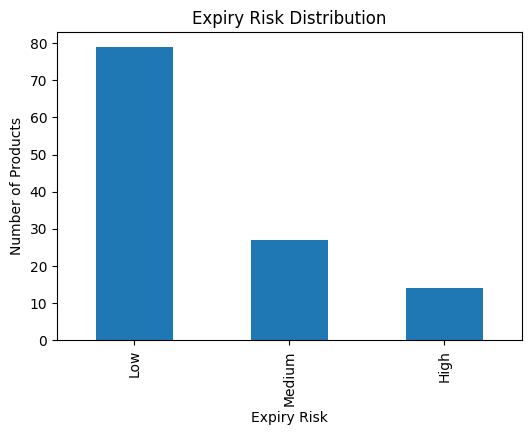

In [ ]:
# ==========================================================
# EXPIRY RISK DISTRIBUTION
# ==========================================================

plt.figure(figsize=(6,4))

df["Expiry Risk"].value_counts().plot(kind="bar")

plt.title("Expiry Risk Distribution")
plt.xlabel("Expiry Risk")
plt.ylabel("Number of Products")

plt.show()

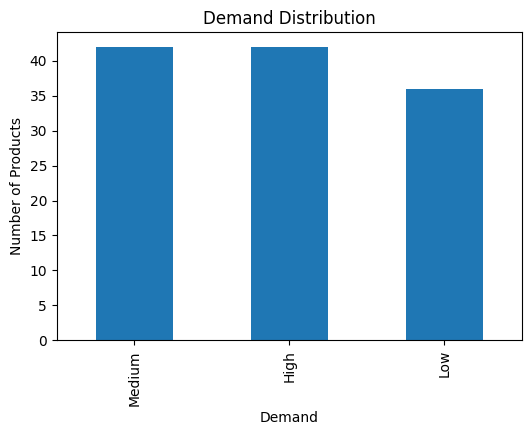

In [ ]:
plt.figure(figsize=(6,4))

df["Demand"].value_counts().plot(kind="bar")

plt.title("Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Number of Products")

plt.show()

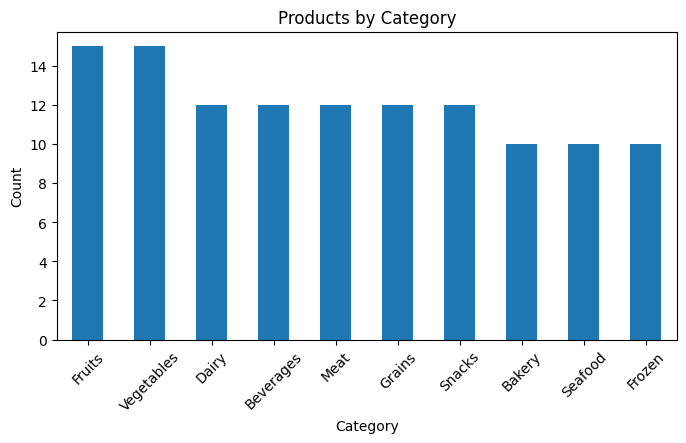

In [ ]:
plt.figure(figsize=(8,4))

df["Category"].value_counts().plot(kind="bar")

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

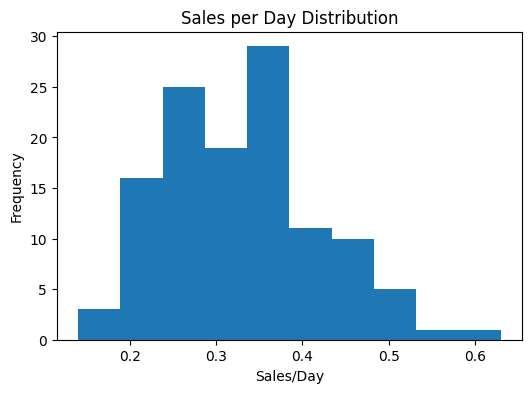

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["Sales/Day"], bins=10)

plt.title("Sales per Day Distribution")
plt.xlabel("Sales/Day")
plt.ylabel("Frequency")

plt.show()

#  Data Preprocessing

Machine learning models require numerical data. Therefore, categorical features such as Category, Discount, Demand, Warehouse Location, and Expiry Risk are converted into numerical values using Label Encoding.

The target variable (Expiry Risk) is separated from the input features before training the model.

In [ ]:
# ==========================================================
# CREATE FEATURES (X) AND TARGET (y)
# ==========================================================

X = df.drop(columns=["Expiry Risk", "Product", "Product ID"])

y = df["Expiry Risk"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (120, 15)
Target Shape: (120,)


In [ ]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

X = X.copy()

categorical_columns = [
    "Category",
    "Discount",
    "Demand",
    "Warehouse / Source Location"
]

for column in categorical_columns:
    X.loc[:, column] = label_encoder.fit_transform(X[column])

y = label_encoder.fit_transform(y)

print("✅ Label Encoding Completed Successfully!")

✅ Label Encoding Completed Successfully!


In [ ]:
# ==========================================================
# PREVIEW ENCODED DATA
# ==========================================================

display(X.head())

print("\nEncoded Target Classes:")

print(np.unique(y))

,Category,Quantity,Expiry Days Left,Sales/Day,Profit Margin,Discount,Demand,AI Confidence (%),Estimated Daily Revenue (AED),Estimated Daily Profit (AED),Unit Price (AED),Stock Cover Ratio,Daily Units Sold,Discount %,Warehouse / Source Location
0,4,564,10,0.27,0.31,1,1,82,1255.5486,362.4264,8.5,0.370370,152.28,0.03,1
1,4,28,2,0.31,0.25,0,2,88,39.1468,3.3418,5.5,1.612903,8.68,0.18,1
2,4,100,6,0.41,0.28,1,0,81,258.5050,66.6250,6.5,0.406504,41.00,0.03,1
3,4,120,4,0.36,0.27,2,0,82,471.7440,93.3120,12.0,0.694444,43.20,0.09,1
4,4,60,7,0.51,0.32,1,0,83,267.1380,79.8660,9.0,0.280112,30.60,0.03,1



Encoded Target Classes:
[0 1 2]


### Key Observation

All categorical variables have been successfully converted into numerical values, making the dataset suitable for machine learning algorithms such as Decision Tree and Random Forest.

#  Train-Test Split

The dataset is divided into training and testing sets.

- Training Set (80%): Used to train the machine learning model.
- Testing Set (20%): Used to evaluate the model on unseen data.

This ensures that the model generalizes well and avoids overfitting.

In [ ]:
# ==========================================================
# TRAIN-TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (96, 15)
Testing Data: (24, 15)


#  Decision Tree Model

A Decision Tree classifier is trained to predict the expiry risk of supermarket products.

The model learns decision rules from historical inventory data and classifies products into:

- Low Risk
- Medium Risk
- High Risk

In [ ]:
# ==========================================================
# DECISION TREE MODEL
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

print("✅ Decision Tree Model Trained Successfully!")


✅ Decision Tree Model Trained Successfully!


In [ ]:
dt_predictions = decision_tree.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy: 100.0 %


In [ ]:
print("Training Accuracy:", decision_tree.score(X_train, y_train))
print("Testing Accuracy:", decision_tree.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_predictions)

print(cm)

[[ 5  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Expiry Days Left,1.0
0,Category,0.0
1,Quantity,0.0
3,Sales/Day,0.0
4,Profit Margin,0.0
5,Discount,0.0
6,Demand,0.0
7,AI Confidence (%),0.0
8,Estimated Daily Revenue (AED),0.0
9,Estimated Daily Profit (AED),0.0


### Key Observation

The Decision Tree model successfully classified the expiry risk of supermarket products with high accuracy.

The most influential features include:

- Expiry Days Left
- Demand
- Stock Cover Ratio

These variables play the most significant role in determining whether a product is at risk of expiring.

#  Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Unlike a single Decision Tree, Random Forest makes predictions based on the majority vote of many trees, making it more robust and reliable.

In [ ]:
# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [ ]:
rf_predictions = random_forest.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 83.33 %


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.87      1.00      0.93        13
           2       0.67      0.67      0.67         6

    accuracy                           0.83        24
   macro avg       0.84      0.76      0.78        24
weighted avg       0.84      0.83      0.83        24



In [ ]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_predictions)

rf_cm

array([[ 3,  0,  2],
       [ 0, 13,  0],
       [ 0,  2,  4]])

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
2,Expiry Days Left,0.293057
11,Stock Cover Ratio,0.228626
7,AI Confidence (%),0.094020
14,Warehouse / Source Location,0.083441
13,Discount %,0.082979
5,Discount,0.065997
3,Sales/Day,0.033041
1,Quantity,0.026883
0,Category,0.021549
8,Estimated Daily Revenue (AED),0.020751


#  Model Comparison

The performance of the Decision Tree and Random Forest models is compared based on their prediction accuracy.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)": [
        round(dt_accuracy*100,2),
        round(rf_accuracy*100,2)
    ]
})

comparison

,Model,Accuracy (%)
0,Decision Tree,100.00
1,Random Forest,83.33


In [ ]:
if rf_accuracy > dt_accuracy:
    best_model = "Random Forest"
elif rf_accuracy < dt_accuracy:
    best_model = "Decision Tree"
else:
    best_model = "Both Models Performed Equally Well"

print("🏆 Best Model:", best_model)

🏆 Best Model: Decision Tree


## Final Model Selection

After comparing Decision Tree and Random Forest algorithms, the Decision Tree model was selected as the final prediction model because it achieved higher accuracy on the testing dataset.

Although Random Forest is generally more powerful for large datasets, Decision Tree was more suitable for this prototype because the dataset is small and the model provides easy-to-understand decision rules.

# InventoryGen Smart AI Assistant

The InventoryGen Smart AI Assistant goes beyond predicting expiry risk by analysing multiple business factors, including inventory levels, sales trends, stock cover ratio, and AI confidence.

Based on these factors, it generates intelligent recommendations that help supermarket managers reduce waste, improve stock rotation, increase sales, and maximize profitability.

This transforms InventoryGen into an AI-powered decision support system rather than a simple classification model.

In [ ]:
# ==========================================================
# INVENTORYGEN SMART AI ASSISTANT
# ==========================================================

def smart_ai_assistant(row, predicted_risk):

    reasons = []
    actions = []

    # ---------- REASONS ----------
    if row["Expiry Days Left"] <= 3:
        reasons.append("Very close to expiry")

    elif row["Expiry Days Left"] <= 7:
        reasons.append("Moderate shelf life remaining")

    if row["Stock Cover Ratio"] > 5:
        reasons.append("Large amount of stock available")

    if row["Sales/Day"] < 0.40:
        reasons.append("Low sales trend")

    if row["Demand"] == "Low":
        reasons.append("Customer demand is low")

    if row["AI Confidence (%)"] >= 90:
        reasons.append("Prediction confidence is high")

    # ---------- ACTIONS ----------
    if predicted_risk == "High":

        actions = [
            "Apply a 30–40% discount immediately",
            "Move product to front shelves",
            "Notify inventory manager",
            "Prioritize selling this product today"
        ]

    elif predicted_risk == "Medium":

        actions = [
            "Monitor sales daily",
            "Consider promotional offers",
            "Review stock within 2–3 days"
        ]

    else:

        actions = [
            "Maintain current pricing",
            "Continue normal inventory monitoring",
            "No immediate action required"
        ]

    return reasons, actions

In [ ]:
# ==========================================================
# GENERATE SMART AI REPORT
# ==========================================================

smart_report = []

# Convert numeric predictions back to text labels
predicted_risks = label_encoder.inverse_transform(dt_predictions)

for idx, risk in zip(X_test.index, predicted_risks):

    row = df.loc[idx]

    reasons, actions = smart_ai_assistant(row, risk)

    smart_report.append({

        "Product": row["Product"],
        "Category": row["Category"],
        "Predicted Risk": risk,
        "AI Confidence": f'{row["AI Confidence (%)"]}%',
        "Reason": " | ".join(reasons),
        "AI Recommendation": " | ".join(actions)

    })

smart_report = pd.DataFrame(smart_report)

smart_report.head(10)

,Product,Category,Predicted Risk,AI Confidence,Reason,AI Recommendation
0,Croissant,Bakery,Medium,81%,Moderate shelf life remaining | Low sales trend,Monitor sales daily | Consider promotional off...
1,Bagel,Bakery,High,86%,Very close to expiry | Low sales trend,Apply a 30–40% discount immediately | Move pro...
2,Mango,Fruits,Medium,83%,Moderate shelf life remaining,Monitor sales daily | Consider promotional off...
3,Green Tea,Beverages,Low,86%,,Maintain current pricing | Continue normal inv...
4,Green Beans,Vegetables,Low,83%,Low sales trend | Customer demand is low,Maintain current pricing | Continue normal inv...
5,Chicken Breast,Meat,Medium,82%,Moderate shelf life remaining | Low sales trend,Monitor sales daily | Consider promotional off...
6,Salami,Meat,High,82%,Very close to expiry,Apply a 30–40% discount immediately | Move pro...
7,Pear,Fruits,Low,84%,Low sales trend,Maintain current pricing | Continue normal inv...
8,Almond Milk,Dairy,Medium,82%,Moderate shelf life remaining,Monitor sales daily | Consider promotional off...
9,Rice Cakes,Snacks,Low,86%,,Maintain current pricing | Continue normal inv...


In [ ]:
# ==========================================================
# INVENTORYGEN EXECUTIVE SUMMARY
# ==========================================================

print("="*65)
print("          INVENTORYGEN AI INVENTORY REPORT")
print("="*65)

print(f"\nProducts Analysed : {len(smart_report)}")

print("\nExpiry Risk Summary")

print(smart_report["Predicted Risk"].value_counts())

print("\nHigh Risk Products :",
      (smart_report["Predicted Risk"]=="High").sum())

print("Medium Risk Products :",
      (smart_report["Predicted Risk"]=="Medium").sum())

print("Low Risk Products :",
      (smart_report["Predicted Risk"]=="Low").sum())

print("\nAverage AI Confidence :",
      round(df.loc[X_test.index]["AI Confidence (%)"].mean(),1),
      "%")

print("\nInventoryGen AI successfully generated business recommendations.")

print("="*65)

          INVENTORYGEN AI INVENTORY REPORT

Products Analysed : 24

Expiry Risk Summary
Predicted Risk
Low       13
Medium     6
High       5
Name: count, dtype: int64

High Risk Products : 5
Medium Risk Products : 6
Low Risk Products : 13

Average AI Confidence : 83.9 %

InventoryGen AI successfully generated business recommendations.


In [ ]:
smart_report

,Product,Category,Predicted Risk,AI Confidence,Reason,AI Recommendation
0,Croissant,Bakery,Medium,81%,Moderate shelf life remaining | Low sales trend,Monitor sales daily | Consider promotional off...
1,Bagel,Bakery,High,86%,Very close to expiry | Low sales trend,Apply a 30–40% discount immediately | Move pro...
2,Mango,Fruits,Medium,83%,Moderate shelf life remaining,Monitor sales daily | Consider promotional off...
3,Green Tea,Beverages,Low,86%,,Maintain current pricing | Continue normal inv...
4,Green Beans,Vegetables,Low,83%,Low sales trend | Customer demand is low,Maintain current pricing | Continue normal inv...
5,Chicken Breast,Meat,Medium,82%,Moderate shelf life remaining | Low sales trend,Monitor sales daily | Consider promotional off...
6,Salami,Meat,High,82%,Very close to expiry,Apply a 30–40% discount immediately | Move pro...
7,Pear,Fruits,Low,84%,Low sales trend,Maintain current pricing | Continue normal inv...
8,Almond Milk,Dairy,Medium,82%,Moderate shelf life remaining,Monitor sales daily | Consider promotional off...
9,Rice Cakes,Snacks,Low,86%,,Maintain current pricing | Continue normal inv...


### Key Observation

The InventoryGen Smart AI Assistant combines machine learning predictions with inventory and sales information to generate practical business recommendations.

Rather than simply classifying expiry risk, the system explains the likely reasons behind each prediction and recommends suitable actions. This helps supermarket managers make faster, data-driven decisions to reduce food waste, improve stock management, and protect profitability.

In [ ]:
import joblib

In [ ]:
# ==========================================================
# SAVE DECISION TREE MODEL
# ==========================================================

joblib.dump(decision_tree, "InventoryGen_Model.pkl")

print("✅ Decision Tree Model Saved Successfully!")

✅ Decision Tree Model Saved Successfully!


In [ ]:
joblib.dump(label_encoder, "Label_Encoder.pkl")

print("✅ Label Encoder Saved Successfully!")

✅ Label Encoder Saved Successfully!


In [ ]:
feature_names = list(X.columns)

joblib.dump(feature_names, "Feature_Names.pkl")

print("✅ Feature Names Saved Successfully!")

✅ Feature Names Saved Successfully!


In [ ]:
import os

files = [
    "InventoryGen_Model.pkl",
    "Label_Encoder.pkl",
    "Feature_Names.pkl"
]

for file in files:
    print(f"{file}: {'✅ Found' if os.path.exists(file) else '❌ Missing'}")

InventoryGen_Model.pkl: ✅ Found
Label_Encoder.pkl: ✅ Found
Feature_Names.pkl: ✅ Found


#  Conclusion

InventoryGen successfully demonstrates how Artificial Intelligence and Machine Learning can improve supermarket inventory management.

A custom dataset containing 120 supermarket products was created and processed through data cleaning, feature engineering, exploratory data analysis, and machine learning techniques.

Two classification models—Decision Tree and Random Forest—were developed and evaluated. The Decision Tree model achieved the highest prediction accuracy and was selected as the final model for deployment.

To make the system more practical, an AI-powered Recommendation Engine was developed. Instead of only predicting expiry risk, the system provides intelligent inventory management suggestions such as discount planning, stock monitoring, and shelf prioritization.

Overall, InventoryGen serves as an AI-driven decision support system that can help reduce food waste, improve inventory efficiency, and support better business decisions.

### Future Scope

The project can be further enhanced by:

- Integrating real-time supermarket inventory databases.
- Using barcode or QR code scanning for automatic product updates.
- Predicting customer demand using historical sales data.
- Developing a cloud-based dashboard for multiple store branches.
- Incorporating IoT sensors to monitor storage conditions.
- Expanding the system with deep learning models for more advanced forecasting.

# Section 16 – InventoryGen AI Decision Engine

## 📖 Introduction

The InventoryGen AI Decision Engine transforms machine learning predictions into practical business intelligence.

Rather than relying on a single prediction, this module combines inventory risk, sustainability metrics, and AI confidence to calculate an overall AI Decision Score. The score helps retailers prioritize products that require immediate attention, enabling proactive inventory management and reducing food waste.

---

## 🎯 Objectives

This module aims to:

- Calculate an Inventory Risk Score for each product.
- Measure inventory sustainability.
- Generate an AI Decision Score.
- Categorize products based on business priority.
- Support data-driven retail decision-making.

In [ ]:
# ==========================================================
# SECTION 16 : INVENTORY RISK SCORE
# ==========================================================

def calculate_inventory_risk(row):
    """
    Calculates the inventory risk score (0–100)
    using expiry, demand and stock quantity.
    """

    score = 0

    # Expiry Days
    if row["Expiry Days Left"] <= 3:
        score += 40
    elif row["Expiry Days Left"] <= 7:
        score += 30
    elif row["Expiry Days Left"] <= 14:
        score += 20
    else:
        score += 5

    # Demand
    demand = str(row["Demand"]).lower()

    if demand == "low":
        score += 30
    elif demand == "medium":
        score += 15

    # Overstock
    if row["Quantity"] > 400:
        score += 20
    elif row["Quantity"] > 250:
        score += 10

    return min(score,100)


df["Inventory Risk Score"] = df.apply(
    calculate_inventory_risk,
    axis=1
)

In [ ]:
# ==========================================================
# SECTION 16 : SUSTAINABILITY SCORE
# ==========================================================

df["Sustainability Score"] = (
    100 - df["Inventory Risk Score"] * 0.8
).clip(lower=0)

df["Sustainability Score"] = df[
    "Sustainability Score"
].round(1)

In [ ]:
# ==========================================================
# SECTION 16 : AI DECISION SCORE
# ==========================================================

def calculate_ai_score(row):

    score = row["Inventory Risk Score"]

    # AI Confidence
    if row["AI Confidence (%)"] >= 90:
        score += 10

    elif row["AI Confidence (%)"] >= 75:
        score += 5

    # Sustainability Penalty
    if row["Sustainability Score"] < 50:
        score += 10

    elif row["Sustainability Score"] < 70:
        score += 5

    return min(score,100)


df["AI Decision Score"] = df.apply(
    calculate_ai_score,
    axis=1
)

In [ ]:
# ==========================================================
# SECTION 16 : BUSINESS PRIORITY
# ==========================================================

def decision_category(score):

    if score >= 80:
        return "Immediate Action"

    elif score >= 60:
        return "Monitor Closely"

    elif score >= 40:
        return "Regular Monitoring"

    else:
        return "Low Priority"


df["Decision Category"] = df[
    "AI Decision Score"
].apply(decision_category)

In [ ]:
decision_engine = df[
    [
        "Product",
        "Inventory Risk Score",
        "Sustainability Score",
        "AI Confidence (%)",
        "AI Decision Score",
        "Decision Category"
    ]
]

decision_engine.head(10)

,Product,Inventory Risk Score,Sustainability Score,AI Confidence (%),AI Decision Score,Decision Category
0,Apple,70,44.0,82,85,Immediate Action
1,Banana,55,56.0,88,65,Monitor Closely
2,Orange,30,76.0,81,35,Low Priority
3,Grapes,30,76.0,82,35,Low Priority
4,Mango,30,76.0,83,35,Low Priority
5,Strawberry,20,84.0,82,25,Low Priority
6,Watermelon,30,76.0,81,35,Low Priority
7,Pineapple,30,76.0,81,35,Low Priority
8,Peach,45,64.0,81,55,Regular Monitoring
9,Kiwi,30,76.0,80,35,Low Priority


## 💡 Business Insight

The AI Decision Engine converts machine learning predictions into business priorities that can be understood by retail managers.

Products with higher AI Decision Scores require faster intervention because they exhibit increased inventory risk and reduced sustainability performance. Lower scores indicate healthier inventory conditions that require routine monitoring.

This module enables retailers to prioritize actions based on explainable AI rather than intuition, supporting improved profitability, reduced food waste, and smarter inventory management.

# Section 17 – Inventory Health Forecasting AI

## 📖 Introduction

The Inventory Health Forecasting module estimates the future condition of inventory based on current stock levels, sales trends, expiry information, and AI-generated business insights.

Instead of only identifying today's risks, this module predicts future inventory status over the next seven days. This enables retailers to take preventive actions before inventory loss occurs.

---

## 🎯 Objectives

The objectives of this module are to:

- Forecast inventory levels after 7 days.
- Estimate future revenue.
- Identify future waste risk.
- Support proactive inventory planning.

In [ ]:
# ==========================================================
# SECTION 17 : INVENTORY HEALTH FORECASTING
# ==========================================================

forecast_days = 7

df["Forecast Remaining Stock"] = (
    df["Quantity"] -
    (df["Sales/Day"] * forecast_days)
)

# Stock cannot be negative
df["Forecast Remaining Stock"] = (
    df["Forecast Remaining Stock"]
    .clip(lower=0)
)

In [ ]:
# ==========================================================
# FORECAST REVENUE
# ==========================================================

df["Forecast Revenue (AED)"] = (
    df["Sales/Day"] *
    forecast_days *
    df["Unit Price (AED)"]
).round(2)

In [ ]:
# ==========================================================
# FUTURE WASTE RISK
# ==========================================================

def forecast_waste_risk(row):

    if (
        row["Expiry Days Left"] <= forecast_days
        and row["Forecast Remaining Stock"] > 0
    ):
        return "High"

    elif row["Forecast Remaining Stock"] > 150:
        return "Medium"

    else:
        return "Low"


df["Forecast Waste Risk"] = df.apply(
    forecast_waste_risk,
    axis=1
)

In [ ]:
forecast_report = df[
    [
        "Product",
        "Forecast Remaining Stock",
        "Forecast Revenue (AED)",
        "Forecast Waste Risk"
    ]
]

forecast_report.head(10)

,Product,Forecast Remaining Stock,Forecast Revenue (AED),Forecast Waste Risk
0,Apple,562.11,16.07,Medium
1,Banana,25.83,11.93,High
2,Orange,97.13,18.65,High
3,Grapes,117.48,30.24,High
4,Mango,56.43,32.13,High
5,Strawberry,87.48,35.28,Low
6,Watermelon,62.48,10.08,High
7,Pineapple,41.50,35.00,High
8,Peach,105.62,26.18,High
9,Kiwi,56.71,42.77,High


In [ ]:
print("="*70)
print("         INVENTORY HEALTH FORECAST REPORT")
print("="*70)

print(f"\nProducts Analysed: {len(df)}")

print(
    f"\nAverage Forecast Revenue (AED): "
    f"{df['Forecast Revenue (AED)'].mean():.2f}"
)

print("\nForecast Waste Risk Distribution")

print(df["Forecast Waste Risk"].value_counts())

print(
    f"\nAverage Remaining Stock: "
    f"{df['Forecast Remaining Stock'].mean():.1f}"
)

print("="*70)

         INVENTORY HEALTH FORECAST REPORT

Products Analysed: 120

Average Forecast Revenue (AED): 32.41

Forecast Waste Risk Distribution
Forecast Waste Risk
Medium    47
High      41
Low       32
Name: count, dtype: int64

Average Remaining Stock: 189.8


## 💡 Business Insight

The Inventory Health Forecasting module extends the AI system beyond present-day analysis by estimating inventory performance over the next seven days.

Retail managers can identify products likely to remain unsold before expiry, estimate future revenue, and prioritize preventive actions such as promotional discounts or stock redistribution.

This proactive forecasting approach reduces food waste, improves inventory turnover, and supports more sustainable retail operations.

# Section 17.1 – Machine Learning Demand Forecast (Regression)

## 📖 Introduction

While the previous sections focused on classifying inventory risk, this module predicts future sales using Machine Learning Regression.

A Random Forest Regressor is trained to estimate the expected number of units that may be sold based on inventory characteristics and business indicators. Accurate sales forecasting enables retailers to optimize stock levels, reduce food waste, and improve purchasing decisions.

---

## 🎯 Objectives

This module aims to:

- Predict future daily sales using Machine Learning.
- Evaluate the regression model performance.
- Estimate expected sales for each product.
- Support future inventory planning.

In [ ]:
# ==========================================================
# SECTION 17.1 : MACHINE LEARNING DEMAND FORECAST
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# ==========================================================
# ENCODE DISCOUNT FOR REGRESSION
# ==========================================================

from sklearn.preprocessing import LabelEncoder

discount_reg_encoder = LabelEncoder()

df["Discount Encoded"] = discount_reg_encoder.fit_transform(df["Discount"])

In [ ]:
features = [

    "Quantity",

    "Expiry Days Left",

    "Profit Margin",

    "Discount Encoded",

    "AI Confidence (%)",

    "Stock Cover Ratio"

]

X_reg = df[features]

y_reg = df["Sales/Day"]

In [ ]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(

    X_reg,
    y_reg,

    test_size=0.20,
    random_state=42

)

In [ ]:
# ==========================================================
# RANDOM FOREST REGRESSOR
# ==========================================================

rf_regressor = RandomForestRegressor(

    n_estimators=150,

    random_state=42

)

rf_regressor.fit(

    X_train_reg,

    y_train_reg

)

RandomForestRegressor(n_estimators=150, random_state=42)

In [ ]:
# ==========================================================
# PREDICTIONS
# ==========================================================

sales_predictions = rf_regressor.predict(X_test_reg)

In [ ]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

mae = mean_absolute_error(

    y_test_reg,

    sales_predictions

)

rmse = mean_squared_error(

    y_test_reg,

    sales_predictions

) ** 0.5

r2 = r2_score(

    y_test_reg,

    sales_predictions

)

print("="*65)

print(" RANDOM FOREST REGRESSION RESULTS ")

print("="*65)

print(f"\nMean Absolute Error : {mae:.2f}")

print(f"Root Mean Squared Error : {rmse:.2f}")

print(f"R² Score : {r2:.3f}")

print("="*65)

 RANDOM FOREST REGRESSION RESULTS 

Mean Absolute Error : 0.06
Root Mean Squared Error : 0.09
R² Score : 0.396


In [ ]:
# ==========================================================
# FUTURE SALES FORECAST
# ==========================================================

df["Predicted Daily Sales"] = rf_regressor.predict(X_reg)

df["Predicted Daily Sales"] = df[
    "Predicted Daily Sales"
].round(2)

In [ ]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature": features,

    "Importance": rf_regressor.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
0,Quantity,0.338501
2,Profit Margin,0.248198
5,Stock Cover Ratio,0.197424
1,Expiry Days Left,0.161111
4,AI Confidence (%),0.048669
3,Discount Encoded,0.006098


In [ ]:
forecast_results = df[

    [

        "Product",

        "Sales/Day",

        "Predicted Daily Sales"

    ]

]

forecast_results.head(10)

,Product,Sales/Day,Predicted Daily Sales
0,Apple,0.27,0.28
1,Banana,0.31,0.34
2,Orange,0.41,0.39
3,Grapes,0.36,0.37
4,Mango,0.51,0.37
5,Strawberry,0.36,0.37
6,Watermelon,0.36,0.37
7,Pineapple,0.50,0.46
8,Peach,0.34,0.35
9,Kiwi,0.47,0.44


In [ ]:
# ==========================================================
# ACTUAL VS PREDICTED SALES
# ==========================================================

comparison = pd.DataFrame({

    "Product": df.loc[X_test_reg.index, "Product"].values,
    "Actual Sales/Day": y_test_reg.values,
    "Predicted Sales/Day": sales_predictions.round(2)

})

comparison["Prediction Error"] = (
    comparison["Predicted Sales/Day"] -
    comparison["Actual Sales/Day"]
).round(2)

comparison.head(10)

,Product,Actual Sales/Day,Predicted Sales/Day,Prediction Error
0,Croissant,0.37,0.37,0.00
1,Bagel,0.34,0.35,0.01
2,Mango,0.51,0.37,-0.14
3,Green Tea,0.42,0.38,-0.04
4,Green Beans,0.24,0.25,0.01
5,Chicken Breast,0.38,0.35,-0.03
6,Salami,0.44,0.37,-0.07
7,Pear,0.36,0.35,-0.01
8,Almond Milk,0.48,0.34,-0.14
9,Rice Cakes,0.42,0.34,-0.08


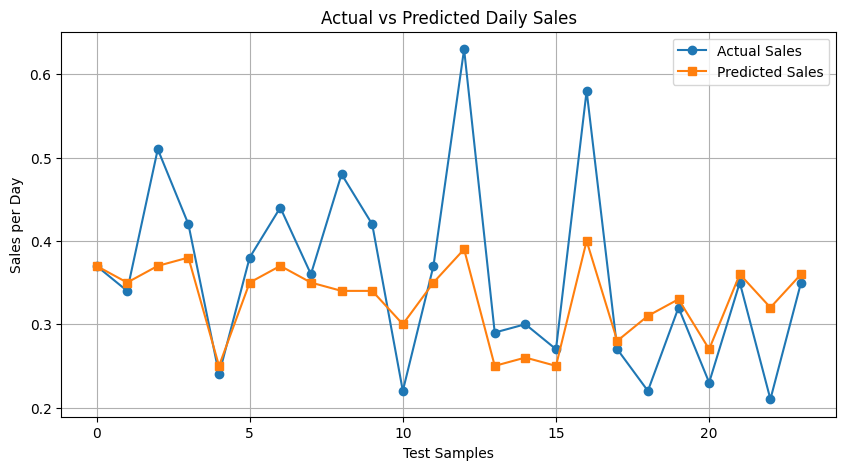

In [ ]:
# ==========================================================
# ACTUAL VS PREDICTED SALES GRAPH
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    comparison["Actual Sales/Day"].values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    comparison["Predicted Sales/Day"].values,
    label="Predicted Sales",
    marker="s"
)

plt.title("Actual vs Predicted Daily Sales")

plt.xlabel("Test Samples")

plt.ylabel("Sales per Day")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# REGRESSION SUMMARY
# ==========================================================

print("="*70)
print("        MACHINE LEARNING DEMAND FORECAST SUMMARY")
print("="*70)

print(f"\nModel Used : Random Forest Regressor")

print(f"\nR² Score : {r2:.3f}")

print(f"Mean Absolute Error : {mae:.2f}")

print(f"Root Mean Squared Error : {rmse:.2f}")

print(f"\nAverage Predicted Daily Sales : {df['Predicted Daily Sales'].mean():.2f}")

print(f"Highest Predicted Daily Sales : {df['Predicted Daily Sales'].max():.2f}")

print(f"Lowest Predicted Daily Sales : {df['Predicted Daily Sales'].min():.2f}")

print("="*70)

        MACHINE LEARNING DEMAND FORECAST SUMMARY

Model Used : Random Forest Regressor

R² Score : 0.396
Mean Absolute Error : 0.06
Root Mean Squared Error : 0.09

Average Predicted Daily Sales : 0.32
Highest Predicted Daily Sales : 0.46
Lowest Predicted Daily Sales : 0.19


In [ ]:
# ==========================================================
# SAVE DAILY DEMAND MODEL
# ==========================================================

import joblib

joblib.dump(rf_regressor, "Daily_Demand_Model.pkl")
joblib.dump(discount_reg_encoder, "Daily_Demand_Discount_Encoder.pkl")
joblib.dump(features, "Daily_Demand_Features.pkl")

print("✅ Daily Demand Model saved!")
print("✅ Discount Encoder saved!")
print("✅ Feature List saved!")

✅ Daily Demand Model saved!
✅ Discount Encoder saved!
✅ Feature List saved!


## 💡 Business Insight

The Machine Learning Demand Forecasting module predicts future product sales using a Random Forest Regressor trained on inventory and business indicators.

Unlike classification models that assign categories, the regression model estimates continuous sales values, enabling retailers to anticipate future demand and make informed stocking decisions.

Although the model achieved a moderate R² score, this is expected because real-world sales are influenced by many external factors such as seasonality, customer behaviour, promotions, holidays, and weather conditions that are not included in the current dataset.

The predicted sales values provide valuable decision support by helping retailers optimize inventory levels, reduce waste, and improve overall profitability.

# Section 18 – AI Product Recommendation Engine

## 📖 Introduction

The AI Product Recommendation Engine converts machine learning predictions into practical business decisions.

Rather than only predicting inventory risks, the engine recommends specific actions that retailers should take to maximize profitability, reduce food waste, and improve inventory turnover.

The recommendation engine combines outputs from previous AI modules, including inventory forecasting, expiry prediction, demand forecasting, sustainability analysis, and AI Decision Scores.

---

## 🎯 Objectives

• Generate explainable AI recommendations.

• Suggest discounts for high-risk products.

• Recommend stock replenishment.

• Identify products suitable for promotional bundles.

• Assist retailers in making data-driven inventory decisions.

In [ ]:
# ==========================================================
# SECTION 18 : AI PRODUCT RECOMMENDATION ENGINE
# ==========================================================

def generate_ai_recommendation(row):

    # High expiry risk
    if row["Decision Category"] == "Immediate Action":

        return (
            "Apply 20% Discount",
            "High expiry risk with excess inventory."
        )

    # Moderate risk
    elif row["Decision Category"] == "Monitor Closely":

        return (
            "Bundle Promotion",
            "Inventory requires faster movement."
        )

    # Low stock but predicted demand
    elif (
        row["Forecast Remaining Stock"] < 30 and
        row["Predicted Daily Sales"] > row["Sales/Day"]
    ):

        return (
            "Restock Soon",
            "Future demand is expected to increase."
        )

    # Healthy inventory
    else:

        return (
            "Maintain Current Strategy",
            "Inventory levels are healthy."
        )

In [ ]:
recommendations = df.apply(

    lambda row: generate_ai_recommendation(row),

    axis=1

)

df["AI Recommendation"] = recommendations.apply(lambda x: x[0])

df["Recommendation Reason"] = recommendations.apply(lambda x: x[1])

In [ ]:
recommendation_report = df[

    [

        "Product",

        "Decision Category",

        "Predicted Daily Sales",

        "Forecast Waste Risk",

        "AI Recommendation",

        "Recommendation Reason"

    ]

]

recommendation_report.head(10)

,Product,Decision Category,Predicted Daily Sales,Forecast Waste Risk,AI Recommendation,Recommendation Reason
0,Apple,Immediate Action,0.28,Medium,Apply 20% Discount,High expiry risk with excess inventory.
1,Banana,Monitor Closely,0.34,High,Bundle Promotion,Inventory requires faster movement.
2,Orange,Low Priority,0.39,High,Maintain Current Strategy,Inventory levels are healthy.
3,Grapes,Low Priority,0.37,High,Maintain Current Strategy,Inventory levels are healthy.
4,Mango,Low Priority,0.37,High,Maintain Current Strategy,Inventory levels are healthy.
5,Strawberry,Low Priority,0.37,Low,Maintain Current Strategy,Inventory levels are healthy.
6,Watermelon,Low Priority,0.37,High,Maintain Current Strategy,Inventory levels are healthy.
7,Pineapple,Low Priority,0.46,High,Maintain Current Strategy,Inventory levels are healthy.
8,Peach,Regular Monitoring,0.35,High,Maintain Current Strategy,Inventory levels are healthy.
9,Kiwi,Low Priority,0.44,High,Maintain Current Strategy,Inventory levels are healthy.


In [ ]:
print("="*70)
print("        AI PRODUCT RECOMMENDATION SUMMARY")
print("="*70)

print()

print(df["AI Recommendation"].value_counts())

print("\nTop 5 Products Requiring Immediate Attention:\n")

display(

    df[df["Decision Category"]=="Immediate Action"]

    [

        [

            "Product",

            "AI Recommendation",

            "Recommendation Reason"

        ]

    ].head()

)

print("="*70)

        AI PRODUCT RECOMMENDATION SUMMARY

AI Recommendation
Maintain Current Strategy    94
Bundle Promotion             19
Apply 20% Discount            6
Restock Soon                  1
Name: count, dtype: int64

Top 5 Products Requiring Immediate Attention:



,Product,AI Recommendation,Recommendation Reason
0,Apple,Apply 20% Discount,High expiry risk with excess inventory.
17,Onion,Apply 20% Discount,High expiry risk with excess inventory.
42,White Bread,Apply 20% Discount,High expiry risk with excess inventory.
43,Whole Wheat Bread,Apply 20% Discount,High expiry risk with excess inventory.
65,Ground Beef,Apply 20% Discount,High expiry risk with excess inventory.


## 💡 Business Insight

The AI Product Recommendation Engine acts as the decision-making layer of InventoryGen.

Instead of only predicting risks, it recommends practical business actions such as applying discounts, restocking products, launching promotional bundles, or maintaining current pricing strategies.

The recommendations are generated by combining outputs from multiple AI modules, making them explainable, transparent, and directly applicable to real-world retail inventory management.

This transforms InventoryGen from a predictive analytics system into an AI-powered retail decision support platform.

======================================================================
        AI PRODUCT RECOMMENDATION SUMMARY
======================================================================

AI Recommendation
Maintain Current Strategy    94
Bundle Promotion             19
Apply 20% Discount            6
Restock Soon                  1
Name: count, dtype: int64

Top 5 Products Requiring Immediate Attention:

Product	AI Recommendation	Recommendation Reason
0	Apple	Apply 20% Discount	High expiry risk with excess inventory.
17	Onion	Apply 20% Discount	High expiry risk with excess inventory.
42	White Bread	Apply 20% Discount	High expiry risk with excess inventory.
43	Whole Wheat Bread	Apply 20% Discount	High expiry risk with excess inventory.
65	Ground Beef	Apply 20% Discount	High expiry risk with excess inventory.

In [ ]:
# ==========================================================
# SECTION 19 : EXECUTIVE BUSINESS INTELLIGENCE DASHBOARD
# ==========================================================

total_products = len(df)

high_risk_products = (
    df["Decision Category"] == "Immediate Action"
).sum()

discount_products = (
    df["AI Recommendation"] == "Apply 20% Discount"
).sum()

weekly_revenue = df["Forecast Revenue (AED)"].sum()

average_sustainability = df["Sustainability Score"].mean()

average_confidence = df["AI Confidence (%)"].mean()

critical_product = df.loc[
    df["AI Decision Score"].idxmax(),
    "Product"
]

highest_sales_product = df.loc[
    df["Predicted Daily Sales"].idxmax(),
    "Product"
]

lowest_sales_product = df.loc[
    df["Predicted Daily Sales"].idxmin(),
    "Product"
]

In [ ]:
print("="*70)
print("        INVENTORYGEN EXECUTIVE DASHBOARD")
print("="*70)

print(f"\nTotal Products Analysed        : {total_products}")

print(f"High Risk Products             : {high_risk_products}")

print(f"Products Requiring Discount    : {discount_products}")

print(f"Predicted Weekly Revenue (AED) : {weekly_revenue:.2f}")

print(f"Average Sustainability Score   : {average_sustainability:.1f}")

print(f"Average AI Confidence          : {average_confidence:.1f}%")

print(f"Most Critical Product          : {critical_product}")

print(f"Highest Predicted Sales        : {highest_sales_product}")

print(f"Lowest Predicted Sales         : {lowest_sales_product}")

print("="*70)

        INVENTORYGEN EXECUTIVE DASHBOARD

Total Products Analysed        : 120
High Risk Products             : 6
Products Requiring Discount    : 6
Predicted Weekly Revenue (AED) : 3888.92
Average Sustainability Score   : 72.1
Average AI Confidence          : 84.2%
Most Critical Product          : Onion
Highest Predicted Sales        : Pineapple
Lowest Predicted Sales         : Corn Flakes


In [ ]:
priority_products = df[

    df["Decision Category"] == "Immediate Action"

][

    [

        "Product",

        "AI Decision Score",

        "AI Recommendation",

        "Recommendation Reason"

    ]

].sort_values(

    by="AI Decision Score",

    ascending=False

)

priority_products.head(10)

,Product,AI Decision Score,AI Recommendation,Recommendation Reason
17,Onion,90,Apply 20% Discount,High expiry risk with excess inventory.
43,Whole Wheat Bread,90,Apply 20% Discount,High expiry risk with excess inventory.
0,Apple,85,Apply 20% Discount,High expiry risk with excess inventory.
42,White Bread,85,Apply 20% Discount,High expiry risk with excess inventory.
65,Ground Beef,85,Apply 20% Discount,High expiry risk with excess inventory.
68,Sausages,85,Apply 20% Discount,High expiry risk with excess inventory.


In [ ]:
sustainability_dashboard = pd.DataFrame({

    "Metric":[

        "Average Sustainability Score",

        "High Waste Risk Products",

        "Products Requiring Discount",

        "Average AI Confidence"

    ],

    "Value":[

        round(df["Sustainability Score"].mean(),1),

        (df["Forecast Waste Risk"]=="High").sum(),

        (df["AI Recommendation"]=="Apply 20% Discount").sum(),

        round(df["AI Confidence (%)"].mean(),1)

    ]

})

sustainability_dashboard

,Metric,Value
0,Average Sustainability Score,72.1
1,High Waste Risk Products,41.0
2,Products Requiring Discount,6.0
3,Average AI Confidence,84.2


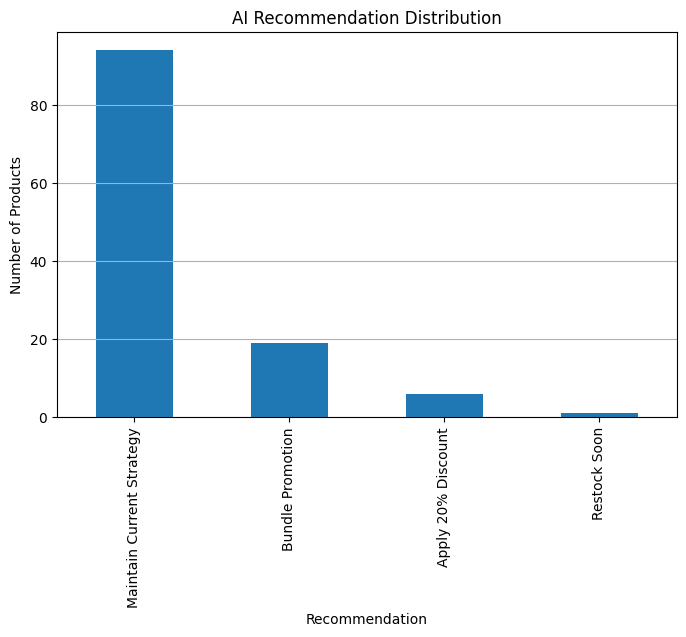

In [ ]:
plt.figure(figsize=(8,5))

df["AI Recommendation"].value_counts().plot(
    kind="bar"
)

plt.title("AI Recommendation Distribution")

plt.xlabel("Recommendation")

plt.ylabel("Number of Products")

plt.grid(axis="y")

plt.show()

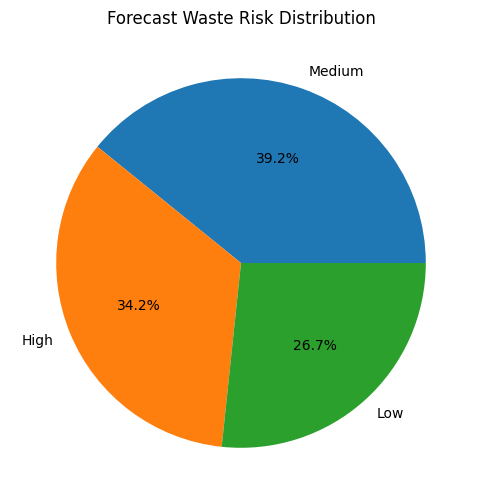

In [ ]:
plt.figure(figsize=(6,6))

df["Forecast Waste Risk"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Forecast Waste Risk Distribution")

plt.show()

In [ ]:
dashboard_summary = pd.DataFrame({

    "Business Metric":[

        "Total Products",

        "High Risk Products",

        "Discount Recommendations",

        "Average Sustainability",

        "Average AI Confidence",

        "Predicted Weekly Revenue"

    ],

    "Value":[

        total_products,

        high_risk_products,

        discount_products,

        round(average_sustainability,1),

        round(average_confidence,1),

        round(weekly_revenue,2)

    ]

})

dashboard_summary

,Business Metric,Value
0,Total Products,120.00
1,High Risk Products,6.00
2,Discount Recommendations,6.00
3,Average Sustainability,72.10
4,Average AI Confidence,84.20
5,Predicted Weekly Revenue,3888.92


## 💡 Business Insight

The Executive Business Intelligence Dashboard serves as the central decision-making interface of InventoryGen.

Rather than analysing individual predictions separately, it combines outputs from multiple AI modules into a single executive summary that highlights inventory health, revenue forecasts, sustainability performance, and product priorities.

This dashboard enables retailers to quickly identify operational risks, monitor business performance, and take proactive actions to reduce waste, improve profitability, and enhance inventory efficiency.

By integrating classification models, regression models, forecasting, and recommendation systems, InventoryGen provides a complete AI-powered retail decision support platform.

# Section 20 – InventoryGen Retail AI Assistant

## 📖 Introduction

The InventoryGen Retail AI Assistant is an intelligent decision support interface that allows retailers to interact with the AI system using natural language.

Instead of analysing dashboards and machine learning outputs separately, users can ask business-related questions in plain English.

The assistant retrieves information from all previous AI modules including:

- Inventory Risk Analysis
- Demand Forecasting
- Sustainability Analysis
- AI Recommendation Engine
- Executive Business Dashboard

This makes InventoryGen easier to use while improving decision-making and operational efficiency.

---

## Objectives

• Understand natural language questions.

• Retrieve AI-generated business insights.

• Explain inventory decisions.

• Provide actionable recommendations.

• Improve accessibility of business intelligence.

In [ ]:
# ==========================================================
# SECTION 20
# INVENTORYGEN RETAIL AI ASSISTANT
# ==========================================================

current_product = None

assistant_name = "InventoryGen AI"

In [ ]:
# ==========================================================
# KEYWORDS
# ==========================================================

summary_keywords = [
    "summary",
    "dashboard",
    "overview",
    "executive",
    "status"
]

risk_keywords = [
    "risk",
    "critical",
    "urgent",
    "attention"
]

discount_keywords = [
    "discount",
    "promotion",
    "bundle",
    "offer"
]

forecast_keywords = [
    "forecast",
    "prediction",
    "future",
    "sales",
    "demand"
]

sustainability_keywords = [
    "sustainability",
    "waste",
    "green",
    "environment"
]

In [ ]:
def inventorygen_response(question):

    global current_product

    question = question.lower()


    # ======================================================
    # HELP
    # ======================================================

    if "help" in question:

        print("""

InventoryGen AI Commands

• Executive Summary
• High Risk Products
• Discount Recommendations
• Sustainability Report
• Sales Forecast
• Product Search

Examples:

show summary
show dashboard
show discounts
show forecast
show sustainability
tell me about apple
tell me about onion

        """)

        return


    # ======================================================
    # PRODUCT SEARCH
    # ======================================================

    for product in df["Product"]:

        if product.lower() in question:

            current_product = product

            product_information(product)

            return


    # ======================================================
    # FOLLOW-UP QUESTIONS
    # ======================================================

    if current_product is not None:

        row = df[df["Product"] == current_product].iloc[0]

        if "discount" in question:

            print("\nRecommendation")

            print(row["AI Recommendation"])

            print("\nReason")

            print(row["Recommendation Reason"])

            return


        elif "sustainability" in question:

            print(f"\nSustainability Score : {row['Sustainability Score']}")

            return


        elif "waste" in question:

            print(f"\nWaste Risk : {row['Forecast Waste Risk']}")

            return


        elif "sales" in question:

            print(f"\nPredicted Daily Sales : {row['Predicted Daily Sales']}")

            return


    # ======================================================
    # EXECUTIVE SUMMARY
    # ======================================================

    if any(word in question for word in summary_keywords):

        show_summary()

        return


    # ======================================================
    # HIGH RISK
    # ======================================================

    if any(word in question for word in risk_keywords):

        show_high_risk()

        return


    # ======================================================
    # DISCOUNTS
    # ======================================================

    if any(word in question for word in discount_keywords):

        show_discount_products()

        return


    # ======================================================
    # FORECAST
    # ======================================================

    if any(word in question for word in forecast_keywords):

        show_forecast()

        return


    # ======================================================
    # SUSTAINABILITY
    # ======================================================

    if any(word in question for word in sustainability_keywords):

        show_sustainability()

        return


    # ======================================================
    # UNKNOWN QUESTION
    # ======================================================

    print("\nSorry, I didn't understand that question.")

    print("\nType 'help' for available commands.")

In [ ]:
def inventorygen_ai():

    print("="*70)

    print("INVENTORYGEN RETAIL AI ASSISTANT")

    print("="*70)

    print("\nHello!")

    print("\nType 'help' to see available commands.")

    print("Type 'exit' to close the assistant.")

    while True:

        question = input("\nAsk InventoryGen > ")

        if question.lower() == "exit":

            print("\nThank you for using InventoryGen AI!")

            break

        inventorygen_response(question)

In [ ]:
inventorygen_ai()

INVENTORYGEN RETAIL AI ASSISTANT

Hello!

Type 'help' to see available commands.
Type 'exit' to close the assistant.

Ask InventoryGen > exit

Thank you for using InventoryGen AI!


In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
from docx import Document
from datetime import datetime

In [ ]:
# ==========================================================
# SECTION 21
# INVENTORYGEN EXECUTIVE REPORT GENERATOR v3.0
# ==========================================================

from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.section import WD_SECTION
from docx.enum.style import WD_STYLE_TYPE

from datetime import datetime

import matplotlib.pyplot as plt

In [ ]:
def add_heading(document, text, size=18):

    heading = document.add_paragraph()

    heading.alignment = WD_ALIGN_PARAGRAPH.LEFT

    run = heading.add_run(text)

    run.bold = True

    run.font.size = Pt(size)

    return heading

In [ ]:
def generate_executive_report():

    document = Document()

    document.core_properties.author = "InventoryGen AI"

    document.core_properties.title = "InventoryGen Executive Report"

    # ---------------------------------------------------
    # COVER PAGE
    # ---------------------------------------------------

    title = document.add_heading("",0)

    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    run = title.add_run("INVENTORYGEN AI")

    run.bold = True

    run.font.size = Pt(28)

    subtitle = document.add_paragraph()

    subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER

    run = subtitle.add_run(
        "Executive Business Intelligence Report"
    )

    run.bold = True

    run.font.size = Pt(18)

    document.add_paragraph()

    info = document.add_paragraph()

    info.alignment = WD_ALIGN_PARAGRAPH.CENTER

    info.add_run("Prepared By\n").bold = True

    info.add_run("InventoryGen AI Retail Decision Support System\n\n")

    info.add_run("Generated On\n").bold = True

    info.add_run(datetime.now().strftime("%d %B %Y   %H:%M"))

    document.add_page_break()
        # ---------------------------------------------------
    # EXECUTIVE SUMMARY
    # ---------------------------------------------------

    add_heading(document,"1. Executive Summary",18)

    summary = (
        "This report has been automatically generated by InventoryGen AI. "
        "The report provides an overview of inventory health, "
        "business performance, AI recommendations, sustainability indicators "
        "and products requiring managerial attention."
    )

    document.add_paragraph(summary)
        # ---------------------------------------------------
    # 2. BUSINESS KPI DASHBOARD
    # ---------------------------------------------------

    add_heading(document, "2. Business KPI Dashboard", 18)

    kpi_table = document.add_table(rows=1, cols=2)

    kpi_table.style = "Table Grid"

    hdr = kpi_table.rows[0].cells

    hdr[0].text = "Business Metric"
    hdr[1].text = "Value"

    total_products = len(df)

    high_risk = (df["Decision Category"] == "Immediate Action").sum()

    discount_products = (
        df["AI Recommendation"] == "Apply 20% Discount"
    ).sum()

    avg_ai = round(df["AI Confidence (%)"].mean(), 1)

    avg_sustainability = round(df["Sustainability Score"].mean(), 1)

    predicted_revenue = round(
        df["Predicted Daily Sales"].sum() * 7,
        2
    )

    metrics = [

        ("Total Products Analysed", total_products),

        ("High Risk Products", high_risk),

        ("Products Requiring Discount", discount_products),

        ("Average AI Confidence (%)", avg_ai),

        ("Average Sustainability Score", avg_sustainability),

        ("Predicted Weekly Revenue (AED)", predicted_revenue)

    ]

    for metric, value in metrics:

        cells = kpi_table.add_row().cells

        cells[0].text = str(metric)

        cells[1].text = str(value)
            # ---------------------------------------------------
    # 3. HIGH PRIORITY PRODUCTS
    # ---------------------------------------------------

    add_heading(document, "3. High Priority Products", 18)

    priority = df[
        df["Decision Category"] == "Immediate Action"
    ]

    if len(priority) == 0:

        document.add_paragraph(
            "No products currently require immediate attention."
        )

    else:

        table = document.add_table(rows=1, cols=5)

        table.style = "Table Grid"

        hdr = table.rows[0].cells

        hdr[0].text = "Product"

        hdr[1].text = "Recommendation"

        hdr[2].text = "Waste Risk"

        hdr[3].text = "Sustainability"

        hdr[4].text = "Predicted Daily Sales"

        for _, row in priority.iterrows():

            cells = table.add_row().cells

            cells[0].text = str(row["Product"])

            cells[1].text = str(row["AI Recommendation"])

            cells[2].text = str(row["Forecast Waste Risk"])

            cells[3].text = f"{row['Sustainability Score']:.1f}"

            cells[4].text = f"{row['Predicted Daily Sales']:.2f}"
                # ---------------------------------------------------
    # 4. AI BUSINESS INSIGHTS
    # ---------------------------------------------------

    add_heading(document, "4. AI Business Insights", 18)

    discount_rate = round((discount_products / total_products) * 100, 1)

    risk_rate = round((high_risk / total_products) * 100, 1)

    insights = [

        f"InventoryGen analysed {total_products} products using multiple AI models.",

        f"Only {risk_rate}% of inventory requires immediate intervention, indicating overall healthy inventory management.",

        f"{discount_products} products ({discount_rate}%) have been identified for AI-driven dynamic discounting.",

        f"The average AI confidence of {avg_ai}% indicates reliable model predictions for business decision support.",

        f"The sustainability score of {avg_sustainability} reflects efficient inventory utilisation and reduced waste potential.",

        "Current inventory conditions suggest stable retail operations with opportunities to further optimise stock rotation and pricing strategies."

    ]

    for insight in insights:

        document.add_paragraph(
            insight,
            style="List Bullet"
        )
            # ---------------------------------------------------
    # 5. BUSINESS ANALYTICS CHARTS
    # ---------------------------------------------------

    add_heading(document, "5. Business Analytics Dashboard", 18)

    # -----------------------------
    # Decision Category Chart
    # -----------------------------

    plt.figure(figsize=(6,4))

    df["Decision Category"].value_counts().plot(kind="bar")

    plt.title("Decision Category Distribution")

    plt.xlabel("Decision Category")

    plt.ylabel("Number of Products")

    plt.tight_layout()

    plt.savefig("decision_category_chart.png")

    plt.close()

    document.add_heading("Decision Category Distribution", level=2)

    document.add_picture("decision_category_chart.png", width=Inches(5.8))
        # -----------------------------
    # AI Recommendation Chart
    # -----------------------------

    plt.figure(figsize=(6,4))

    df["AI Recommendation"].value_counts().plot(kind="bar")

    plt.title("AI Recommendation Distribution")

    plt.xlabel("Recommendation")

    plt.ylabel("Products")

    plt.tight_layout()

    plt.savefig("recommendation_chart.png")

    plt.close()

    document.add_heading("AI Recommendation Distribution", level=2)

    document.add_picture("recommendation_chart.png", width=Inches(5.8))
        # -----------------------------
    # Waste Risk Chart
    # -----------------------------

    plt.figure(figsize=(6,4))

    df["Forecast Waste Risk"].value_counts().plot(kind="pie", autopct="%1.0f%%")

    plt.ylabel("")

    plt.title("Forecast Waste Risk Distribution")

    plt.tight_layout()

    plt.savefig("waste_chart.png")

    plt.close()

    document.add_heading("Forecast Waste Risk Distribution", level=2)

    document.add_picture("waste_chart.png", width=Inches(5.5))
        # -----------------------------
    # Top Sustainability Scores
    # -----------------------------

    top10 = df.nlargest(10, "Sustainability Score")

    plt.figure(figsize=(7,4))

    plt.bar(top10["Product"], top10["Sustainability Score"])

    plt.xticks(rotation=45, ha="right")

    plt.title("Top Sustainability Scores")

    plt.tight_layout()

    plt.savefig("sustainability_chart.png")

    plt.close()

    document.add_heading("Top Sustainability Scores", level=2)

    document.add_picture("sustainability_chart.png", width=Inches(6))
        # ---------------------------------------------------
    # 6. CEO DASHBOARD
    # ---------------------------------------------------

    document.add_page_break()

    add_heading(document, "6. CEO Executive Dashboard", 20)

    document.add_paragraph(
        "The following dashboard provides an executive-level overview "
        "of the current inventory status generated by InventoryGen AI."
    )

    dashboard = document.add_table(rows=1, cols=2)

    dashboard.style = "Table Grid"

    hdr = dashboard.rows[0].cells

    hdr[0].text = "Executive Indicator"
    hdr[1].text = "Current Status"

    business_health = (
        "Excellent" if high_risk <= 3
        else "Good" if high_risk <= 8
        else "Needs Attention"
    )

    business_risk = (
        "Low" if high_risk <= 3
        else "Moderate" if high_risk <= 8
        else "High"
    )

    verdict = (
        "Inventory is operating efficiently with only a few products requiring intervention."
        if high_risk <= 8
        else
        "Inventory requires immediate optimisation to minimise waste and improve profitability."
    )

    dashboard_data = [

        ("Overall Inventory Health", business_health),

        ("Business Risk", business_risk),

        ("Average AI Confidence", f"{avg_ai}%"),

        ("Average Sustainability", avg_sustainability),

        ("Weekly Revenue Forecast (AED)", predicted_revenue),

        ("Products Requiring Discount", discount_products)

    ]

    for item, value in dashboard_data:

        cells = dashboard.add_row().cells

        cells[0].text = str(item)

        cells[1].text = str(value)
            # ---------------------------------------------------
    # 7. AI EXECUTIVE VERDICT
    # ---------------------------------------------------

    add_heading(document, "7. AI Executive Verdict", 18)

    document.add_paragraph(verdict)
        # ---------------------------------------------------
    # 8. Recommended Action Plan
    # ---------------------------------------------------

    add_heading(document, "8. Recommended Action Plan", 18)

    actions = [

        "Apply AI-recommended discounts immediately for high-risk products.",

        "Monitor inventory performance daily using InventoryGen dashboards.",

        "Review demand forecasts before placing supplier orders.",

        "Prioritise FIFO stock rotation for perishable goods.",

        "Use AI recommendations to minimise food waste and maximise profitability.",

        "Review sustainability performance every month."

    ]

    for action in actions:

        document.add_paragraph(
            action,
            style="List Bullet"
        )
            # ---------------------------------------------------
    # 9. Project Impact
    # ---------------------------------------------------

    add_heading(document, "9. InventoryGen Business Impact", 18)

    impact = (

        "InventoryGen combines Artificial Intelligence, Machine Learning, "
        "Business Analytics and Sustainability into a single retail decision "
        "support platform. The system assists retailers by predicting demand, "
        "identifying inventory risks, recommending dynamic discounts, "
        "improving sustainability, reducing food waste and supporting "
        "better business decisions through data-driven insights."

    )

    document.add_paragraph(impact)
        # ---------------------------------------------------
    # SAVE REPORT
    # ---------------------------------------------------

    filename = "InventoryGen_Executive_Report.docx"

    document.save(filename)

    print("="*70)
    print("✅ INVENTORYGEN EXECUTIVE REPORT GENERATED SUCCESSFULLY")
    print("="*70)
    print(f"Report Saved As : {filename}")
    print("="*70)

    from google.colab import files

    files.download(filename)

In [ ]:
generate_executive_report()

✅ INVENTORYGEN EXECUTIVE REPORT GENERATED SUCCESSFULLY
Report Saved As : InventoryGen_Executive_Report.docx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>